# Совместная оценка толщины слоя и трёх удельных сопротивлений

## Цель расчёта

Для каждого из двух испытуемых отдельно оцениваются четыре параметра:

\[
\boldsymbol{\theta}=\left(h,\rho_1,\rho_{2,\mathrm{вдох}},\rho_{2,\mathrm{выдох}}\right),
\]

где $h$ — эффективная толщина первого слоя; $\rho_1$ — удельное сопротивление первого слоя; $\rho_{2,\mathrm{вдох}}$ и $\rho_{2,\mathrm{выдох}}$ — удельные сопротивления второго слоя в двух состояниях дыхания.

Динамика $\rho_2$ в этом ноутбуке представлена двумя дискретными состояниями — вдохом и выдохом. Непрерывная временная траектория $\rho_2(t)$ здесь не восстанавливается.

Внутри одного испытуемого $h$ и $\rho_1$ считаются одинаковыми для всех электродных сборок и обоих состояний дыхания. Для каждого состояния вводится только одно общее значение $\rho_2$, также одинаковое для всех сборок. Следовательно, итоговыми неизвестными являются не отдельные значения для каждой сборки, а ровно четыре общих параметра.

Это расчётная проверка двуслойной модели бокового монтажа. Она не является расчётом функции сердца и не подтверждает клиническую применимость параметров.


## Что измерено и что принято как допущение

**Измеренные входы.** Из ноутбука `33.06` используются характерные размеры сборок $a_i$ и сводные значения импеданса на вдохе и выдохе. Для каждого испытуемого расчёт выполняется независимо.

**Модельное допущение.** Для рассматриваемых сборок принимается применимой прямая двуслойная модель из ноутбука `30.01`. Её обозначим через $F$. Для каждой сборки записываются два уравнения:

\[
Z^{\mathrm{набл}}_{i,\mathrm{вдох}}=F\!\left(a_i,h,\rho_1,\rho_{2,\mathrm{вдох}}\right)+r_{i,\mathrm{вдох}},
\]

\[
Z^{\mathrm{набл}}_{i,\mathrm{выдох}}=F\!\left(a_i,h,\rho_1,\rho_{2,\mathrm{выдох}}\right)+r_{i,\mathrm{выдох}},
\]

где $Z^{\mathrm{набл}}$ — наблюдаемый импеданс; $F$ — импеданс, предсказанный двуслойной моделью; $r$ — остаток между наблюдением и моделью. Остаток здесь не объявляется случайным гауссовским шумом: в него могут входить межзаписная физиологическая изменчивость, различия контакта и положения электродов, аппаратные эффекты и несоответствие плоской двуслойной модели реальной анатомии.

В идеальном эксперименте при верной модели все сборки одного испытуемого должны описываться одним $\rho_{2,\mathrm{вдох}}$ и одним $\rho_{2,\mathrm{выдох}}$. В реальных данных точное равенство всех уравнений обычно невозможно. Поэтому находится не «лучшее физиологическое значение само по себе», а набор общих параметров, который в заданных границах даёт наименьшее расхождение модели с измеренными $Z$.


## Критерий подбора и роль наблюдаемого импеданса

Основной критерий — среднеквадратичное расхождение по всем сборкам и обоим состояниям:

\[
Q(\boldsymbol{\theta})=
\sqrt{\frac{1}{2N}\sum_{i=1}^{N}
\left[
\left(F_{i,\mathrm{вдох}}-Z^{\mathrm{набл}}_{i,\mathrm{вдох}}\right)^2+
\left(F_{i,\mathrm{выдох}}-Z^{\mathrm{набл}}_{i,\mathrm{выдох}}\right)^2
\right]},
\]

где $N$ — число сборок; $F_{i,s}$ — модельный импеданс для сборки $i$ и состояния $s$; $Q$ измеряется в омах.

Наблюдаемый $Z$ является опорой расчёта: именно с ним сравнивается модель. Однако отдельного «опорного решения» по параметрам $h$ и $\rho$ здесь нет. Минимум $Q$ показывает лишь наиболее согласованный с данными набор параметров внутри принятых границ. Он не доказывает истинность этих параметров.

Все остатки пока имеют одинаковый вес, потому что подтверждённые индивидуальные оценки неопределённости для записей отсутствуют. Это расчётное допущение.


## Ограничения параметров

Параметры подбираются только внутри положительной и предварительно физиологически мотивированной области.

| Параметр | Основной рабочий сценарий | Расширенный сценарий чувствительности | Статус границ |
|---|---:|---:|---|
| $h$ | 10–50 мм | 5–60 мм | диапазон вокруг имеющихся индивидуальных КТ-ориентиров; эффективная и анатомическая толщина не считаются тождественными |
| $\rho_1$ | 3–15 Ом·м | 1–30 Ом·м | предварительный диапазон вокруг значений, использованных в локальной модели `30.01` |
| $\rho_{2,\mathrm{вдох}}$, $\rho_{2,\mathrm{выдох}}$ | 10–25 Ом·м | 5–50 Ом·м | предварительный рабочий диапазон лёгочной ткани из локальной постановки `30.01` |

Основной сценарий используется для предметной интерпретации. Расширенный сценарий нужен только для проверки, продолжает ли уменьшаться невязка за его границами. Его более широкий диапазон нельзя называть независимо подтверждённой физиологической нормой.

Дополнительно проверяется ожидаемое для этой постановки неравенство $\rho_{2,\mathrm{вдох}}\geq\rho_{2,\mathrm{выдох}}$. Частотно-зависимые физиологические границы ещё должны быть подтверждены по принятой литературе и независимым данным. Поэтому текущие численные границы являются рабочим допущением, а не валидированным справочным интервалом.


In [1]:
import hashlib
import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "exploratory_analysis.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "Colab Notebooks"
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

from exploratory_analysis import (
    fit_static_at_h_bounded,
    fit_static_bounded,
    profile_static_h_bounded,
    rho2_consistency_at_h_rho1,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

CONFIG_PATH = NOTEBOOK_DIR / "config" / "exp02_paths.local.json"
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
SOURCE_PATH = (
    Path(config["derived_root"])
    / "exp02"
    / "exploratory"
    / "33.06_side_arrays_exploratory.json"
)
source = json.loads(SOURCE_PATH.read_text(encoding="utf-8"))
if len(source.get("subjects", {})) != 2:
    raise RuntimeError("Расчёт ожидает ровно двух испытуемых в артефакте 33.06")

SUBJECT_NAMES = {"exp02_georg": "Георг", "exp02_nik": "Ник"}
PRIMARY = {
    "h": (0.010, 0.050),
    "rho1": (3.0, 15.0),
    "rho2": (10.0, 25.0),
}
EXPANDED = {
    "h": (0.005, 0.060),
    "rho1": (1.0, 30.0),
    "rho2": (5.0, 50.0),
}

BOUND_LABELS = {
    "h": "h",
    "rho1": "ρ₁",
    "rho2_inhale": "ρ₂ на вдохе",
    "rho2_exhale": "ρ₂ на выдохе",
}


In [2]:
def subject_arrays(subject):
    sizes_m = np.asarray(subject["sizes_mm"], dtype=float) / 1000.0
    z_inhale = np.asarray(subject["observed_z_inhale_ohm"], dtype=float)
    z_exhale = np.asarray(subject["observed_z_exhale_ohm"], dtype=float)
    return sizes_m, z_inhale, z_exhale


def fit_scenario(subject, bounds):
    sizes_m, z_inhale, z_exhale = subject_arrays(subject)
    fit = fit_static_bounded(
        sizes_m,
        z_inhale,
        z_exhale,
        h_bounds_m=bounds["h"],
        rho1_bounds_ohm_m=bounds["rho1"],
        rho2_bounds_ohm_m=bounds["rho2"],
    )
    h_grid = np.arange(bounds["h"][0], bounds["h"][1] + 0.0001, 0.001)
    profile = profile_static_h_bounded(
        sizes_m,
        z_inhale,
        z_exhale,
        h_grid,
        rho1_bounds_ohm_m=bounds["rho1"],
        rho2_bounds_ohm_m=bounds["rho2"],
    )
    return fit, profile


results = {}
for subject_id, subject in source["subjects"].items():
    primary_fit, primary_profile = fit_scenario(subject, PRIMARY)
    expanded_fit, expanded_profile = fit_scenario(subject, EXPANDED)
    if not primary_fit["rho2_inhale_not_less_than_exhale"]:
        raise RuntimeError(f"Для {subject_id} нарушен принятый порядок rho2")
    results[subject_id] = {
        "primary_fit": primary_fit,
        "primary_profile": primary_profile,
        "expanded_fit": expanded_fit,
        "expanded_profile": expanded_profile,
    }


summary_rows = []
for subject_id, result in results.items():
    fit = result["primary_fit"]
    bound_names = [BOUND_LABELS[name] for name, hit in fit["parameter_bound_hits"].items() if hit]
    summary_rows.append({
        "Испытуемый": SUBJECT_NAMES.get(subject_id, subject_id),
        "h, мм": 1000.0 * fit["h_m"],
        "ρ₁, Ом·м": fit["rho1_ohm_m"],
        "ρ₂ на вдохе, Ом·м": fit["rho2_inhale_ohm_m"],
        "ρ₂ на выдохе, Ом·м": fit["rho2_exhale_ohm_m"],
        "RMS, Ом": fit["residual_rms_ohm"],
        "относительная RMS, %": 100.0 * fit["relative_residual_rms"],
        "границы": ", ".join(bound_names) if bound_names else "нет",
        "ранг якобиана": fit["jacobian_log_rank"],
        "число обусловленности": fit["jacobian_log_condition"],
    })

summary = pd.DataFrame(summary_rows)
display(summary.style.format({
    "h, мм": "{:.2f}",
    "ρ₁, Ом·м": "{:.3f}",
    "ρ₂ на вдохе, Ом·м": "{:.3f}",
    "ρ₂ на выдохе, Ом·м": "{:.3f}",
    "RMS, Ом": "{:.3f}",
    "относительная RMS, %": "{:.2f}",
    "число обусловленности": "{:.1f}",
}))


,Испытуемый,"h, мм","ρ₁, Ом·м","ρ₂ на вдохе, Ом·м","ρ₂ на выдохе, Ом·м","RMS, Ом","относительная RMS, %",границы,ранг якобиана,число обусловленности
0,Георг,10.00,9.267,25.000,24.867,9.959,5.67,"h, ρ₂ на вдохе",4,47.1
1,Ник,10.00,3.920,14.120,12.384,6.589,8.56,h,4,46.9


## Как читать основную таблицу

- $h$ и три $\rho$ — общий набор параметров для всех сборок одного испытуемого.
- RMS показывает типичный по величине разрыв между измеренным и рассчитанным импедансом. Это мера согласия с данными, а не физиологическая погрешность параметров.
- Пометка в столбце «границы» означает, что оптимизатор хотел продолжить движение за пределы принятой области. Такой результат зависит от выбранной границы и не является внутренним устойчивым решением.
- Полный ранг якобиана является только локальной математической проверкой. Большое число обусловленности означает, что небольшое изменение данных может заметно изменить параметры. Оно не заменяет проверку на независимых данных.

Многократный запуск из 17 начальных точек используется против случайного выбора локального решения. Совпадение запусков проверяет работу оптимизатора, но само по себе не устраняет зависимость от границ и модели.


In [3]:
expanded_rows = []
for subject_id, result in results.items():
    primary = result["primary_fit"]
    expanded = result["expanded_fit"]
    expanded_rows.append({
        "Испытуемый": SUBJECT_NAMES.get(subject_id, subject_id),
        "h: основной, мм": 1000.0 * primary["h_m"],
        "h: расширенный, мм": 1000.0 * expanded["h_m"],
        "RMS: основная, Ом": primary["residual_rms_ohm"],
        "RMS: расширенная, Ом": expanded["residual_rms_ohm"],
        "изменение RMS, %": 100.0 * (
            expanded["residual_rms_ohm"] / primary["residual_rms_ohm"] - 1.0
        ),
        "ρ₁: расширенный, Ом·м": expanded["rho1_ohm_m"],
        "ρ₂ на вдохе: расширенный, Ом·м": expanded["rho2_inhale_ohm_m"],
        "ρ₂ на выдохе: расширенный, Ом·м": expanded["rho2_exhale_ohm_m"],
        "граница расширенного": ", ".join(
            BOUND_LABELS[name] for name, hit in expanded["parameter_bound_hits"].items() if hit
        ) or "нет",
    })

expanded_summary = pd.DataFrame(expanded_rows)
display(expanded_summary.style.format({
    column: "{:.3f}"
    for column in expanded_summary.columns
    if column not in {"Испытуемый", "граница расширенного"}
}))


,Испытуемый,"h: основной, мм","h: расширенный, мм","RMS: основная, Ом","RMS: расширенная, Ом","изменение RMS, %","ρ₁: расширенный, Ом·м","ρ₂ на вдохе: расширенный, Ом·м","ρ₂ на выдохе: расширенный, Ом·м",граница расширенного
0,Георг,10.000,5.000,9.959,7.735,-22.328,4.835,28.110,26.455,h
1,Ник,10.000,5.000,6.589,6.152,-6.635,2.308,12.843,11.562,h


## Рисунок 1. Совместная подгонка, профиль по толщине и компенсация параметров

**Слева — измерение и модель.** Точки показывают наблюдаемые импедансы, линии — значения двуслойной модели при одном общем наборе параметров. Вертикальное расстояние между точкой и линией является остатком. Систематический рисунок остатков указывает, что одних четырёх параметров недостаточно для описания всех сборок.

**В центре — профиль по толщине.** Для каждой фиксированной $h$ заново подбираются три общих удельных сопротивления и показывается минимально достижимая RMS. Внутренний выраженный минимум означал бы, что данные предпочитают некоторую толщину. Если кривая продолжает снижаться к границе, данные не локализуют $h$ внутри принятого диапазона.

**Справа — компенсация параметров.** Показано, как три подобранных $\rho$ меняются вслед за принудительным изменением $h$. Здесь «компенсация» означает, что изменение удельного сопротивления частично возмещает влияние толщины на расчётный $Z$. Если параметры сильно меняются, а RMS остаётся близкой, они взаимозаменяемы в данной постановке и оцениваются неустойчиво.

Ранее использованная поверхность $D(h,\rho_1)$ была мерой разброса вспомогательных, отдельно восстановленных $\rho_2$ между сборками. Она не является поверхностью импеданса и не используется ниже как главный критерий, потому что в текущей постановке одно общее $\rho_2$ для каждого состояния входит непосредственно в совместную подгонку. Смысл $D$ сохранён в отдельной диагностике ниже.


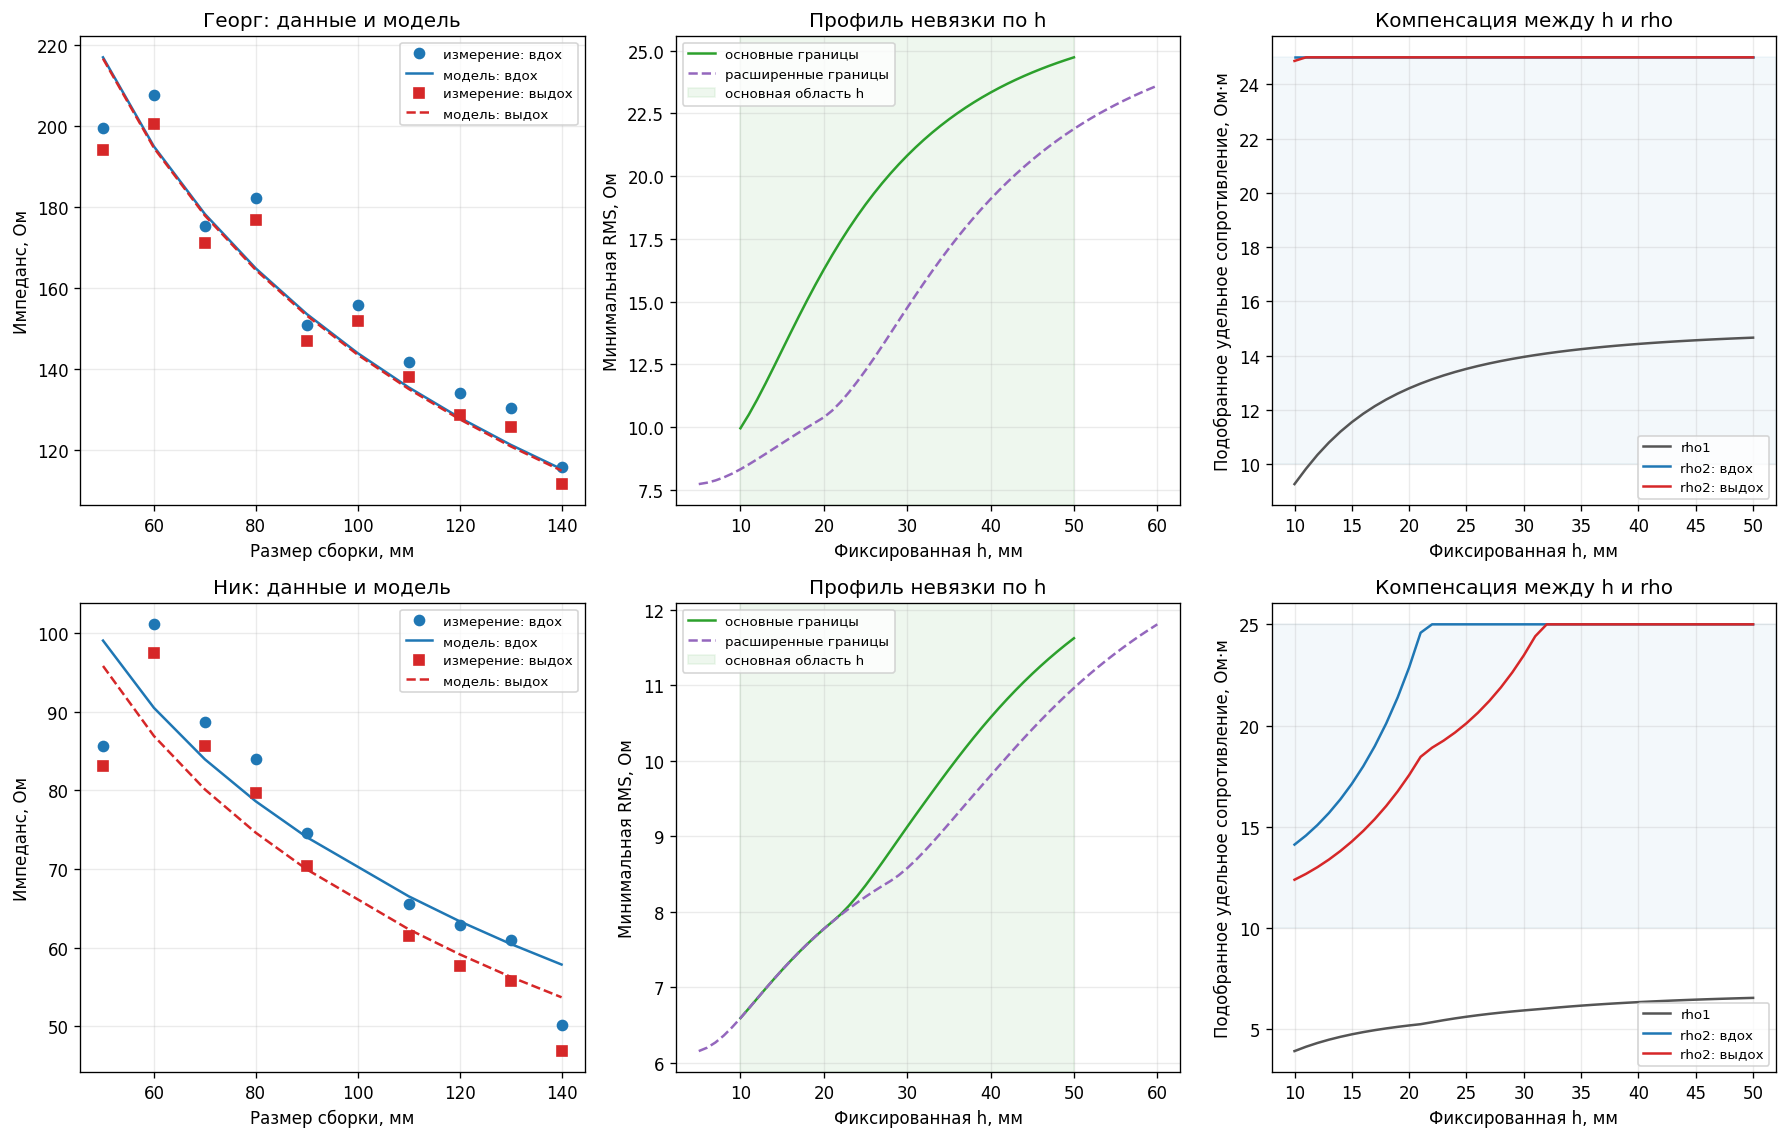

In [4]:
fig, axes = plt.subplots(len(results), 3, figsize=(15, 4.8 * len(results)))
if len(results) == 1:
    axes = np.asarray([axes])

for row_index, (subject_id, result) in enumerate(results.items()):
    subject = source["subjects"][subject_id]
    sizes_m, z_inhale, z_exhale = subject_arrays(subject)
    sizes_mm = 1000.0 * sizes_m
    fit = result["primary_fit"]

    ax = axes[row_index, 0]
    ax.plot(sizes_mm, z_inhale, "o", color="#1f77b4", label="измерение: вдох")
    ax.plot(sizes_mm, fit["predicted_inhale_ohm"], "-", color="#1f77b4", label="модель: вдох")
    ax.plot(sizes_mm, z_exhale, "s", color="#d62728", label="измерение: выдох")
    ax.plot(sizes_mm, fit["predicted_exhale_ohm"], "--", color="#d62728", label="модель: выдох")
    ax.set_xlabel("Размер сборки, мм")
    ax.set_ylabel("Импеданс, Ом")
    ax.set_title(f"{SUBJECT_NAMES.get(subject_id, subject_id)}: данные и модель")
    ax.legend(fontsize=8)

    ax = axes[row_index, 1]
    for scenario_name, color, linestyle in (
        ("primary_profile", "#2ca02c", "-"),
        ("expanded_profile", "#9467bd", "--"),
    ):
        profile = result[scenario_name]["profile"]
        label = "основные границы" if scenario_name == "primary_profile" else "расширенные границы"
        ax.plot(
            [1000.0 * item["h_m"] for item in profile],
            [item["residual_rms_ohm"] for item in profile],
            linestyle,
            color=color,
            label=label,
        )
    ax.axvspan(10, 50, color="#2ca02c", alpha=0.08, label="основная область h")
    ax.set_xlabel("Фиксированная h, мм")
    ax.set_ylabel("Минимальная RMS, Ом")
    ax.set_title("Профиль невязки по h")
    ax.legend(fontsize=8)

    ax = axes[row_index, 2]
    profile = result["primary_profile"]["profile"]
    h_mm = [1000.0 * item["h_m"] for item in profile]
    ax.plot(h_mm, [item["rho1_ohm_m"] for item in profile], label="rho1", color="#555555")
    ax.plot(h_mm, [item["rho2_inhale_ohm_m"] for item in profile], label="rho2: вдох", color="#1f77b4")
    ax.plot(h_mm, [item["rho2_exhale_ohm_m"] for item in profile], label="rho2: выдох", color="#d62728")
    ax.axhspan(PRIMARY["rho2"][0], PRIMARY["rho2"][1], color="#1f77b4", alpha=0.05)
    ax.set_xlabel("Фиксированная h, мм")
    ax.set_ylabel("Подобранное удельное сопротивление, Ом·м")
    ax.set_title("Компенсация между h и rho")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Наблюдаемая структура на рисунке 1

**Левые панели: совпадение расчётной кривой с измеренными импедансами.** По горизонтали отложен размер электродной сборки, по вертикали — импеданс. Синие круги и красные квадраты являются измеренными значениями на вдохе и выдохе. Синие и красные линии рассчитаны при одном общем наборе параметров для всех размеров. Если модель полностью описывала бы измерения, каждая точка находилась бы на линии соответствующего состояния. Расстояние от точки до линии показывает остаток для конкретной сборки; последовательное расположение нескольких точек выше или ниже линии образует систематическую структуру остатков.

У Георга расчётные кривые передают общее уменьшение импеданса с ростом размера сборки, однако отдельные точки чередуются относительно линии. Итоговая RMS составляет 9,959 Ом, или 5,67 % в относительном выражении. При этом $\rho_{2,\mathrm{вдох}}$ уже достигает верхней границы 25 Ом·м, а $\rho_{2,\mathrm{выдох}}$ находится рядом с ней. Поэтому визуально приемлемое воспроизведение общего тренда не означает, что удельное сопротивление второго слоя определено.

У Ника модель также воспроизводит нисходящий тренд, но наибольшие расхождения заметны для крайних и некоторых малых размеров, прежде всего 50, 60 и 140 мм. RMS равна 6,589 Ом, однако относительная RMS выше, чем у Георга, и составляет 8,56 %. Различие абсолютной и относительной RMS связано с меньшим уровнем импеданса у Ника. Сравнивать испытуемых только по абсолютному значению RMS поэтому недостаточно.

**Средние панели: профиль невязки по толщине.** Каждая точка зелёной или фиолетовой кривой получена после фиксации $h$ и повторного подбора трёх удельных сопротивлений. Значение по вертикали является минимальной RMS, достижимой при данной толщине. Искомая толщина была бы поддержана данными, если бы профиль имел выраженный внутренний минимум: RMS уменьшалась бы при приближении к некоторой $h$, а затем возрастала по обе стороны от неё.

У обоих испытуемых такой формы нет. В основной области минимальная RMS достигается при $h=10$ мм, а после расширения области — при $h=5$ мм. Профиль возрастает по мере увеличения $h$. Следовательно, данные продолжают предпочитать меньшую эффективную толщину и не локализуют её внутри проверенного диапазона. Этот результат относится к параметру плоской двуслойной модели. Он не означает, что анатомическая толщина мягких тканей равна 5 или 10 мм.

**Правые панели: компенсация между толщиной и удельными сопротивлениями.** По горизонтали задана фиксированная $h$, а линии показывают значения трёх $\rho$, которые минимизируют RMS при этой толщине. Возрастание $\rho$ вместе с $h$ означает, что изменение одного параметра частично компенсирует изменение другого и сохраняет близкую форму рассчитанного импеданса.

У Ника при увеличении $h$ обе оценки $\rho_2$ возрастают и последовательно достигают верхней границы. Поэтому одна и та же совокупность импедансов допускает разные сочетания толщины и удельных сопротивлений. У Георга $\rho_2$ находится у верхней границы почти на всём основном диапазоне, тогда как изменение $h$ в основном компенсируется ростом $\rho_1$. Такая картина указывает на слабую чувствительность данных к конечному значению $\rho_2$.

**Вывод из рисунка 1.** Совместная подгонка воспроизводит общий размерный тренд импеданса, но не даёт устойчивой оценки $h$. У Ника выражена взаимная компенсация $h$ и $\rho_2$; у Георга оценка $\rho_2$ ограничена верхней границей. Поэтому значения в основной таблице являются условными параметрами на границе выбранной области, а не независимо определёнными свойствами тканей.


## Рисунок 2. Устойчивость к исключению одной сборки

Для каждого размера расчёт повторяется после его исключения. Такая проверка отвечает на простой вопрос: остаётся ли решение примерно тем же, если одна электродная сборка отсутствует?

Устойчивая оценка не должна определяться единственной записью. Сильный сдвиг после исключения одной сборки может быть следствием особого расположения электродов, контакта, межзаписного изменения состояния или недостаточности двуслойной модели. Эта проверка не устанавливает причину, а только обнаруживает влияние записи на итоговый результат.


,Испытуемый,"h: минимум, мм","h: максимум, мм","ρ₁: минимум, Ом·м","ρ₁: максимум, Ом·м","ρ₂ на вдохе: минимум, Ом·м","ρ₂ на вдохе: максимум, Ом·м","ρ₂ на выдохе: минимум, Ом·м","ρ₂ на выдохе: максимум, Ом·м","RMS: минимум, Ом","RMS: максимум, Ом"
0,Георг,10.000,10.000,9.089,9.959,25.000,25.000,23.800,25.000,6.563,10.464
1,Ник,10.000,13.913,3.558,5.958,11.396,15.911,10.000,13.773,1.997,6.987


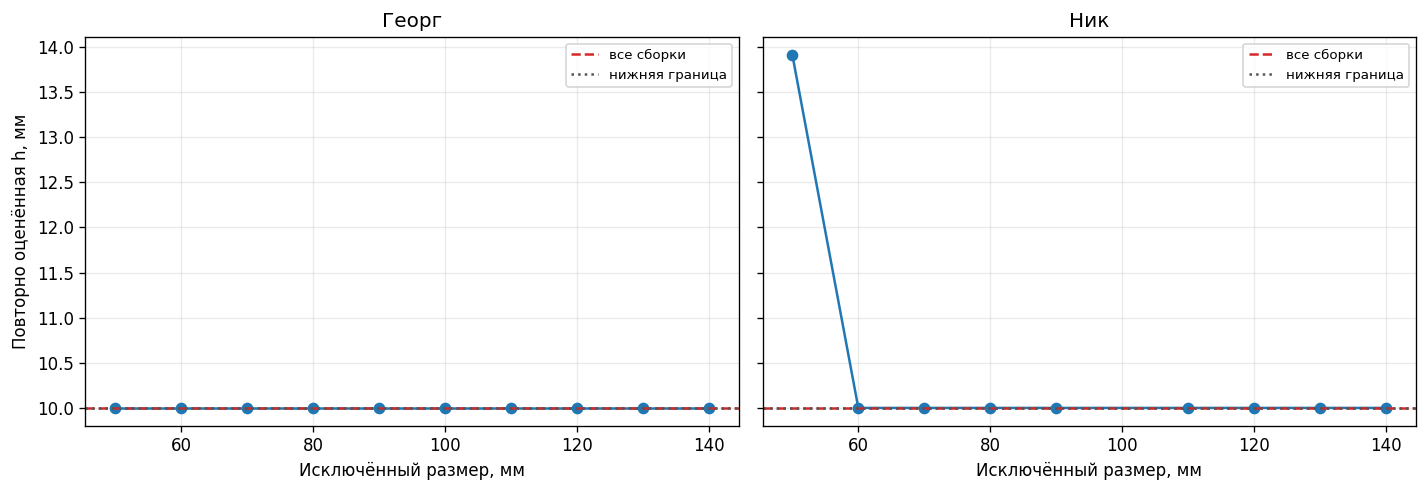

In [5]:
loo_rows = []
for subject_id, subject in source["subjects"].items():
    sizes_m, z_inhale, z_exhale = subject_arrays(subject)
    for omitted_index in range(len(sizes_m)):
        keep = np.arange(len(sizes_m)) != omitted_index
        fit = fit_static_bounded(
            sizes_m[keep],
            z_inhale[keep],
            z_exhale[keep],
            h_bounds_m=PRIMARY["h"],
            rho1_bounds_ohm_m=PRIMARY["rho1"],
            rho2_bounds_ohm_m=PRIMARY["rho2"],
        )
        loo_rows.append({
            "subject_id": subject_id,
            "Испытуемый": SUBJECT_NAMES.get(subject_id, subject_id),
            "Исключённый размер, мм": 1000.0 * sizes_m[omitted_index],
            "h, мм": 1000.0 * fit["h_m"],
            "ρ₁, Ом·м": fit["rho1_ohm_m"],
            "ρ₂ на вдохе, Ом·м": fit["rho2_inhale_ohm_m"],
            "ρ₂ на выдохе, Ом·м": fit["rho2_exhale_ohm_m"],
            "RMS, Ом": fit["residual_rms_ohm"],
            "Есть граничный параметр": any(fit["parameter_bound_hits"].values()),
        })

loo = pd.DataFrame(loo_rows)
loo_summary = (
    loo.groupby("Испытуемый", sort=False)
    .agg(
        h_min_mm=("h, мм", "min"),
        h_max_mm=("h, мм", "max"),
        rho1_min=("ρ₁, Ом·м", "min"),
        rho1_max=("ρ₁, Ом·м", "max"),
        rho2_in_min=("ρ₂ на вдохе, Ом·м", "min"),
        rho2_in_max=("ρ₂ на вдохе, Ом·м", "max"),
        rho2_ex_min=("ρ₂ на выдохе, Ом·м", "min"),
        rho2_ex_max=("ρ₂ на выдохе, Ом·м", "max"),
        rms_min=("RMS, Ом", "min"),
        rms_max=("RMS, Ом", "max"),
    )
    .reset_index()
    .rename(columns={
        "h_min_mm": "h: минимум, мм",
        "h_max_mm": "h: максимум, мм",
        "rho1_min": "ρ₁: минимум, Ом·м",
        "rho1_max": "ρ₁: максимум, Ом·м",
        "rho2_in_min": "ρ₂ на вдохе: минимум, Ом·м",
        "rho2_in_max": "ρ₂ на вдохе: максимум, Ом·м",
        "rho2_ex_min": "ρ₂ на выдохе: минимум, Ом·м",
        "rho2_ex_max": "ρ₂ на выдохе: максимум, Ом·м",
        "rms_min": "RMS: минимум, Ом",
        "rms_max": "RMS: максимум, Ом",
    })
)
display(loo_summary.style.format({column: "{:.3f}" for column in loo_summary.columns if column != "Испытуемый"}))

fig, axes = plt.subplots(1, len(results), figsize=(12, 4.2), sharey=True)
if len(results) == 1:
    axes = [axes]
for ax, (subject_id, result) in zip(axes, results.items()):
    subset = loo[loo["subject_id"] == subject_id]
    ax.plot(subset["Исключённый размер, мм"], subset["h, мм"], "o-")
    ax.axhline(1000.0 * result["primary_fit"]["h_m"], color="#d62728", linestyle="--", label="все сборки")
    ax.axhline(10.0, color="#555555", linestyle=":", label="нижняя граница")
    ax.set_xlabel("Исключённый размер, мм")
    ax.set_title(SUBJECT_NAMES.get(subject_id, subject_id))
    ax.legend(fontsize=8)
axes[0].set_ylabel("Повторно оценённая h, мм")
plt.tight_layout()
plt.show()


### Наблюдаемая структура на рисунке 2

По горизонтали указан размер сборки, исключённой из повторного расчёта. По вертикали показана вновь оценённая толщина $h$. Красная пунктирная линия соответствует расчёту по всем сборкам, а серая линия обозначает нижнюю границу 10 мм. Каждая синяя точка отвечает на вопрос, изменится ли оценка толщины после удаления одной конкретной записи.

У Георга все синие точки остаются на уровне 10 мм. Ни исключение малых сборок, ни исключение больших сборок не создаёт внутреннего минимума. Следовательно, граничная оценка $h$ не определяется одной аномальной записью: направление к меньшей толщине сохраняется во всём наборе.

У Ника результат иной. После исключения большинства размеров оценка также остаётся на нижней границе. Только исключение сборки 50 мм сдвигает её приблизительно до 13,9 мм. Одновременно RMS уменьшается примерно до 2,00 Ом. Это показывает сильное влияние записи 50 мм на форму размерной зависимости. Уменьшение RMS после исключения нельзя автоматически считать улучшением метода, поскольку число наблюдений стало меньше и удалена наиболее влиятельная точка. Кроме того, сама запись 50 мм не признана ошибочной: возможны особенности чувствительности малой сборки, контакта, положения электродов или состояния испытуемого.

**Вывод из рисунка 2.** Для Георга граничность является свойством всей совокупности данных при данной модели. Для Ника оценка дополнительно зависит от сборки 50 мм. Поэтому простое удаление отдельных размеров не решает обратную задачу: для Георга требуется другая чувствительность измерительной схемы или дополнительная информация, а для Ника — повторная экспериментальная проверка наиболее влиятельной сборки.


## Рисунок 3. Межсборочная согласованность вспомогательных оценок $\rho_2$

Чтобы непосредственно проверить исходную идею, можно временно отказаться от общего $\rho_2$ и для каждой сборки отдельно найти такое вспомогательное $\rho_{2,i,s}$, которое точно воспроизводит её наблюдаемый $Z$. В этом вспомогательном обращении $h$ и $\rho_1$ фиксируются на значениях совместной подгонки.

Если данные и двуслойная модель полностью совместимы, все точки одного состояния совпадут. Их разброс описывается показателем

\[
D=\sqrt{\frac{1}{2N}\sum_{s}\sum_{i=1}^{N}
\left(\ln \rho_{2,i,s}-\overline{\ln \rho_{2,s}}\right)^2},
\]

где $\rho_{2,i,s}$ — вспомогательное значение для сборки $i$ и состояния $s$; $\overline{\ln \rho_{2,s}}$ — среднее логарифмов в пределах одного состояния. При $D=0$ все сборки дают одно значение; $\exp(D)$ показывает типичный мультипликативный разброс.

Эта диагностика отвечает на вопрос о межсборочной согласованности, но не выбирает итоговые четыре параметра и не заменяет невязку по измеренному импедансу.


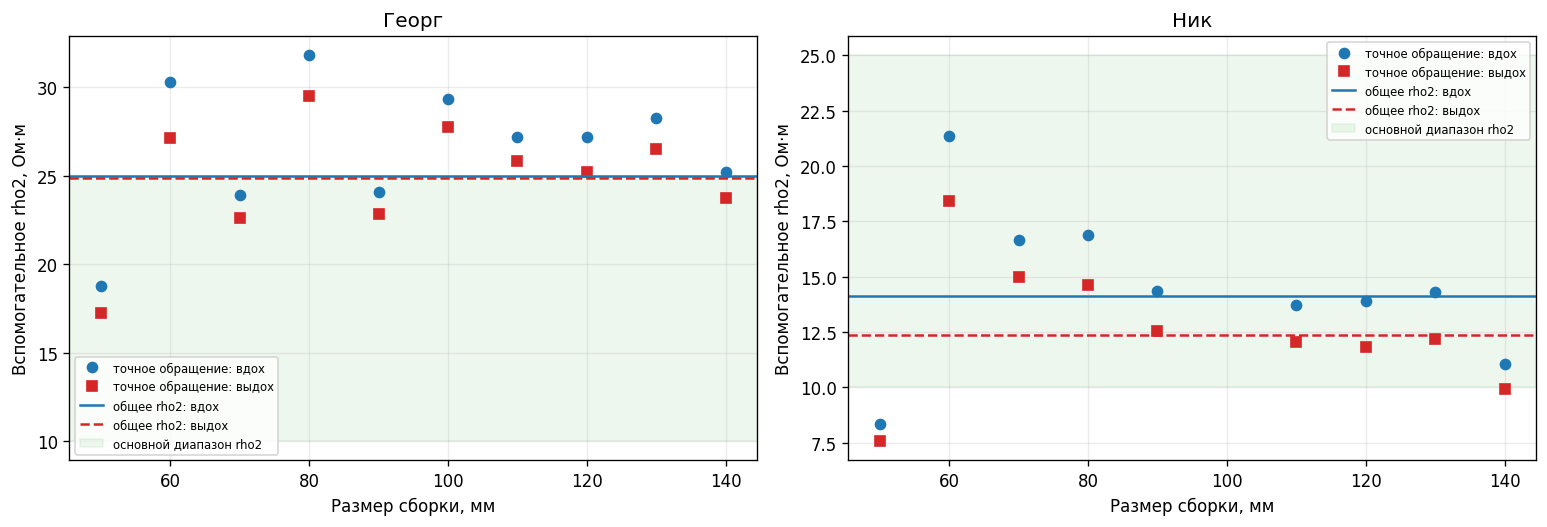

,Испытуемый,D,exp(D),"ρ₂ на вдохе: минимум, Ом·м","ρ₂ на вдохе: максимум, Ом·м","ρ₂ на выдохе: минимум, Ом·м","ρ₂ на выдохе: максимум, Ом·м"
0,Георг,0.144,1.155,18.773,31.818,17.225,29.533
1,Ник,0.246,1.278,8.348,21.375,7.570,18.424


In [6]:
diagnostic_rows = []
diagnostics = {}
fig, axes = plt.subplots(1, len(results), figsize=(13, 4.5), sharey=False)
if len(results) == 1:
    axes = [axes]

for ax, (subject_id, result) in zip(axes, results.items()):
    subject = source["subjects"][subject_id]
    sizes_m, z_inhale, z_exhale = subject_arrays(subject)
    fit = result["primary_fit"]
    diagnostic = rho2_consistency_at_h_rho1(
        sizes_m,
        z_inhale,
        z_exhale,
        fit["h_m"],
        fit["rho1_ohm_m"],
        rho2_bounds_ohm_m=(0.01, 1000.0),
    )
    diagnostics[subject_id] = diagnostic
    diagnostic_rows.append({
        "Испытуемый": SUBJECT_NAMES.get(subject_id, subject_id),
        "D": diagnostic["rho2_log_spread_rms"],
        "exp(D)": diagnostic["rho2_multiplicative_spread"],
        "ρ₂ на вдохе: минимум, Ом·м": diagnostic["inhale"]["rho2_min_ohm_m"],
        "ρ₂ на вдохе: максимум, Ом·м": diagnostic["inhale"]["rho2_max_ohm_m"],
        "ρ₂ на выдохе: минимум, Ом·м": diagnostic["exhale"]["rho2_min_ohm_m"],
        "ρ₂ на выдохе: максимум, Ом·м": diagnostic["exhale"]["rho2_max_ohm_m"],
    })

    sizes_mm = 1000.0 * sizes_m
    ax.plot(sizes_mm, diagnostic["rho2_inhale_ohm_m"], "o", color="#1f77b4", label="точное обращение: вдох")
    ax.plot(sizes_mm, diagnostic["rho2_exhale_ohm_m"], "s", color="#d62728", label="точное обращение: выдох")
    ax.axhline(fit["rho2_inhale_ohm_m"], color="#1f77b4", linestyle="-", label="общее rho2: вдох")
    ax.axhline(fit["rho2_exhale_ohm_m"], color="#d62728", linestyle="--", label="общее rho2: выдох")
    ax.axhspan(PRIMARY["rho2"][0], PRIMARY["rho2"][1], color="#2ca02c", alpha=0.08, label="основной диапазон rho2")
    ax.set_xlabel("Размер сборки, мм")
    ax.set_ylabel("Вспомогательное rho2, Ом·м")
    ax.set_title(SUBJECT_NAMES.get(subject_id, subject_id))
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

diagnostic_summary = pd.DataFrame(diagnostic_rows)
display(diagnostic_summary.style.format({column: "{:.3f}" for column in diagnostic_summary.columns if column != "Испытуемый"}))


### Наблюдаемая структура на рисунке 3

Каждая синяя или красная точка показывает вспомогательное $\rho_{2,i}$, которое требуется отдельной сборке для точного воспроизведения её измеренного импеданса при фиксированных $h$ и $\rho_1$. Горизонтальные линии соответствуют общим $\rho_{2,\mathrm{вдох}}$ и $\rho_{2,\mathrm{выдох}}$ из совместной подгонки. Зелёная полоса обозначает основной рабочий диапазон 10–25 Ом·м; она не является доверительным интервалом и не описывает погрешность.

В идеальном случае точки одного состояния располагались бы на одной горизонтали. У Георга значения на вдохе изменяются приблизительно от 18,8 до 31,8 Ом·м, а на выдохе — от 17,2 до 29,5 Ом·м. Общие оценки находятся около 25 Ом·м, однако нескольким сборкам для точного совпадения требуется значение выше рабочего диапазона. Показатель $D=0{,}144$, а $\exp(D)=1{,}155$: типичный логарифмический разброс соответствует мультипликативному коэффициенту около 1,16.

У Ника диапазон ещё шире: приблизительно 8,35–21,38 Ом·м на вдохе и 7,57–18,42 Ом·м на выдохе. Некоторые малые и большие сборки требуют значений ниже основной границы. Здесь $D=0{,}246$, а $\exp(D)=1{,}278$, то есть типичный мультипликативный разброс составляет около 1,28.

Меньший $D$ у Георга не противоречит граничной оценке $\rho_2$. Показатель $D$ характеризует согласованность отдельных точных обращений при уже выбранных $h$ и $\rho_1$, но не измеряет чувствительность импеданса к изменению $\rho_2$. Параметр может давать сравнительно небольшой межсборочный разброс и одновременно оставаться неидентифицируемым, если широкий диапазон больших $\rho_2$ почти одинаково влияет на импеданс.

**Вывод из рисунка 3.** Требование одного общего $\rho_2$ для всех сборок выполняется лишь приближённо. Разброс вспомогательных оценок показывает несовпадение реальных записей с идеальной двуслойной постановкой. Его возможными источниками остаются межзаписная изменчивость, контакт и положение электродов, аппаратные эффекты и недостаточность геометрической модели; сам рисунок не разделяет эти причины.


## Оценка удельных сопротивлений при фиксированной толщине по КТ

В проекте исторически использовались две толщины мягких тканей: 15 мм для Ника и 40 мм для Георга. Эти значения были перенесены из ручной КТ-сегментации в Inobitec. Текущий ноутбук не вычисляет толщину повторно по DICOM, тканевым маскам или STL и не проверяет место измерения. Поэтому далее используется термин **«исторический КТ-референс»**, а не утверждение о заново подтверждённой анатомической толщине.

После фиксации $h$ неизвестными остаются три общих параметра:

\[
\boldsymbol{\eta}=\left(\rho_1,\rho_{2,\mathrm{вдох}},\rho_{2,\mathrm{выдох}}\right),
\]

где $\rho_1$ — общее удельное сопротивление первого слоя; $\rho_{2,\mathrm{вдох}}$ и $\rho_{2,\mathrm{выдох}}$ — общие для всех сборок удельные сопротивления второго слоя в двух состояниях дыхания.

Критерий RMS остаётся тем же, но $h$ больше не подбирается. Такой расчёт отвечает на вопрос, можно ли при заданной КТ-толщине описать все наблюдаемые импедансы одним $\rho_1$ и двумя значениями $\rho_2$. Он не проверяет правильность самого КТ-измерения.


In [7]:
CT_H_M = {"exp02_nik": 0.015, "exp02_georg": 0.040}
CT_TECHNICAL_BOUNDS = {"rho1": (0.5, 60.0), "rho2": (1.0, 200.0)}

ct_results = {}
for subject_id, subject in source["subjects"].items():
    sizes_m, z_inhale, z_exhale = subject_arrays(subject)
    h_ct = CT_H_M[subject_id]
    primary_fit = fit_static_at_h_bounded(
        sizes_m,
        z_inhale,
        z_exhale,
        h_ct,
        rho1_bounds_ohm_m=PRIMARY["rho1"],
        rho2_bounds_ohm_m=PRIMARY["rho2"],
    )
    expanded_fit = fit_static_at_h_bounded(
        sizes_m,
        z_inhale,
        z_exhale,
        h_ct,
        rho1_bounds_ohm_m=EXPANDED["rho1"],
        rho2_bounds_ohm_m=EXPANDED["rho2"],
    )
    technical_fit = fit_static_at_h_bounded(
        sizes_m,
        z_inhale,
        z_exhale,
        h_ct,
        rho1_bounds_ohm_m=CT_TECHNICAL_BOUNDS["rho1"],
        rho2_bounds_ohm_m=CT_TECHNICAL_BOUNDS["rho2"],
    )

    loo_rows_ct = []
    for omitted_index in range(len(sizes_m)):
        keep = np.arange(len(sizes_m)) != omitted_index
        loo_fit = fit_static_at_h_bounded(
            sizes_m[keep],
            z_inhale[keep],
            z_exhale[keep],
            h_ct,
            rho1_bounds_ohm_m=PRIMARY["rho1"],
            rho2_bounds_ohm_m=PRIMARY["rho2"],
        )
        loo_rows_ct.append({
            "omitted_size_mm": float(1000.0 * sizes_m[omitted_index]),
            **loo_fit,
        })

    ct_results[subject_id] = {
        "h_ct_m": h_ct,
        "primary_fit": primary_fit,
        "expanded_fit": expanded_fit,
        "technical_fit": technical_fit,
        "leave_one_size_out": loo_rows_ct,
    }


ct_rows = []
for subject_id, result in ct_results.items():
    fit = result["primary_fit"]
    free_fit = results[subject_id]["primary_fit"]
    bound_names = [BOUND_LABELS[name] for name, hit in fit["parameter_bound_hits"].items() if hit]
    ct_rows.append({
        "Испытуемый": SUBJECT_NAMES.get(subject_id, subject_id),
        "h по КТ, мм": 1000.0 * result["h_ct_m"],
        "ρ₁, Ом·м": fit["rho1_ohm_m"],
        "ρ₂ на вдохе, Ом·м": fit["rho2_inhale_ohm_m"],
        "ρ₂ на выдохе, Ом·м": fit["rho2_exhale_ohm_m"],
        "RMS при h по КТ, Ом": fit["residual_rms_ohm"],
        "относительная RMS, %": 100.0 * fit["relative_residual_rms"],
        "изменение RMS к свободной h, %": 100.0 * (
            fit["residual_rms_ohm"] / free_fit["residual_rms_ohm"] - 1.0
        ),
        "границы": ", ".join(bound_names) if bound_names else "нет",
        "число обусловленности": fit["jacobian_log_condition_fixed_h"],
    })

ct_summary = pd.DataFrame(ct_rows)
display(ct_summary.style.format({
    "h по КТ, мм": "{:.1f}",
    "ρ₁, Ом·м": "{:.3f}",
    "ρ₂ на вдохе, Ом·м": "{:.3f}",
    "ρ₂ на выдохе, Ом·м": "{:.3f}",
    "RMS при h по КТ, Ом": "{:.3f}",
    "относительная RMS, %": "{:.2f}",
    "изменение RMS к свободной h, %": "{:+.1f}",
    "число обусловленности": "{:.1f}",
}))


ct_sensitivity_rows = []
for subject_id, result in ct_results.items():
    expanded = result["expanded_fit"]
    technical = result["technical_fit"]
    ct_sensitivity_rows.append({
        "Испытуемый": SUBJECT_NAMES.get(subject_id, subject_id),
        "ρ₂ на вдохе: расширенный, Ом·м": expanded["rho2_inhale_ohm_m"],
        "ρ₂ на выдохе: расширенный, Ом·м": expanded["rho2_exhale_ohm_m"],
        "RMS: расширенная область, Ом": expanded["residual_rms_ohm"],
        "границы расширенной области": ", ".join(
            BOUND_LABELS[name] for name, hit in expanded["parameter_bound_hits"].items() if hit
        ) or "нет",
        "ρ₂ на вдохе: технический предел, Ом·м": technical["rho2_inhale_ohm_m"],
        "ρ₂ на выдохе: технический предел, Ом·м": technical["rho2_exhale_ohm_m"],
        "RMS: техническая область, Ом": technical["residual_rms_ohm"],
        "границы технической области": ", ".join(
            BOUND_LABELS[name] for name, hit in technical["parameter_bound_hits"].items() if hit
        ) or "нет",
    })

ct_sensitivity = pd.DataFrame(ct_sensitivity_rows)
display(ct_sensitivity.style.format({
    column: "{:.3f}"
    for column in ct_sensitivity.columns
    if column not in {
        "Испытуемый",
        "границы расширенной области",
        "границы технической области",
    }
}))


,Испытуемый,"h по КТ, мм","ρ₁, Ом·м","ρ₂ на вдохе, Ом·м","ρ₂ на выдохе, Ом·м","RMS при h по КТ, Ом","относительная RMS, %","изменение RMS к свободной h, %",границы,число обусловленности
0,Георг,40.0,14.435,25.000,25.000,23.331,14.54,+134.3,"ρ₂ на вдохе, ρ₂ на выдохе",24.5
1,Ник,15.0,4.749,17.123,14.273,7.227,9.41,+9.7,нет,7.9


,Испытуемый,"ρ₂ на вдохе: расширенный, Ом·м","ρ₂ на выдохе: расширенный, Ом·м","RMS: расширенная область, Ом",границы расширенной области,"ρ₂ на вдохе: технический предел, Ом·м","ρ₂ на выдохе: технический предел, Ом·м","RMS: техническая область, Ом",границы технической области
0,Георг,50.000,50.000,19.088,"ρ₂ на вдохе, ρ₂ на выдохе",200.000,200.000,15.099,"ρ₂ на вдохе, ρ₂ на выдохе"
1,Ник,17.123,14.273,7.227,нет,17.123,14.273,7.227,нет


## Рисунок 4. Согласие модели с данными при фиксированной толщине по КТ

Основная таблица содержит результат в тех же предварительных рабочих границах, что и расчёт со свободной $h$. Столбец изменения RMS сравнивает две модели на одних данных: положительное значение означает, что фиксация $h$ по КТ ухудшила согласие двуслойной модели с измеренными импедансами.

Расширенная область $\rho_2=5\text{–}50$ Ом·м используется как проверка чувствительности. Техническая область $\rho_2=1\text{–}200$ Ом·м воспроизводит широкий исторический предел и показывает направление движения решения. Значения около 200 Ом·м не интерпретируются как физиологический результат.

Если $\rho_2$ остаётся на верхней границе после её расширения, данные при данной $h$ не задают внутреннего конечного значения $\rho_2$. Совпадение граничных оценок на вдохе и выдохе в таком случае является свойством ограниченного оптимизатора и не доказывает отсутствия дыхательного изменения ткани.


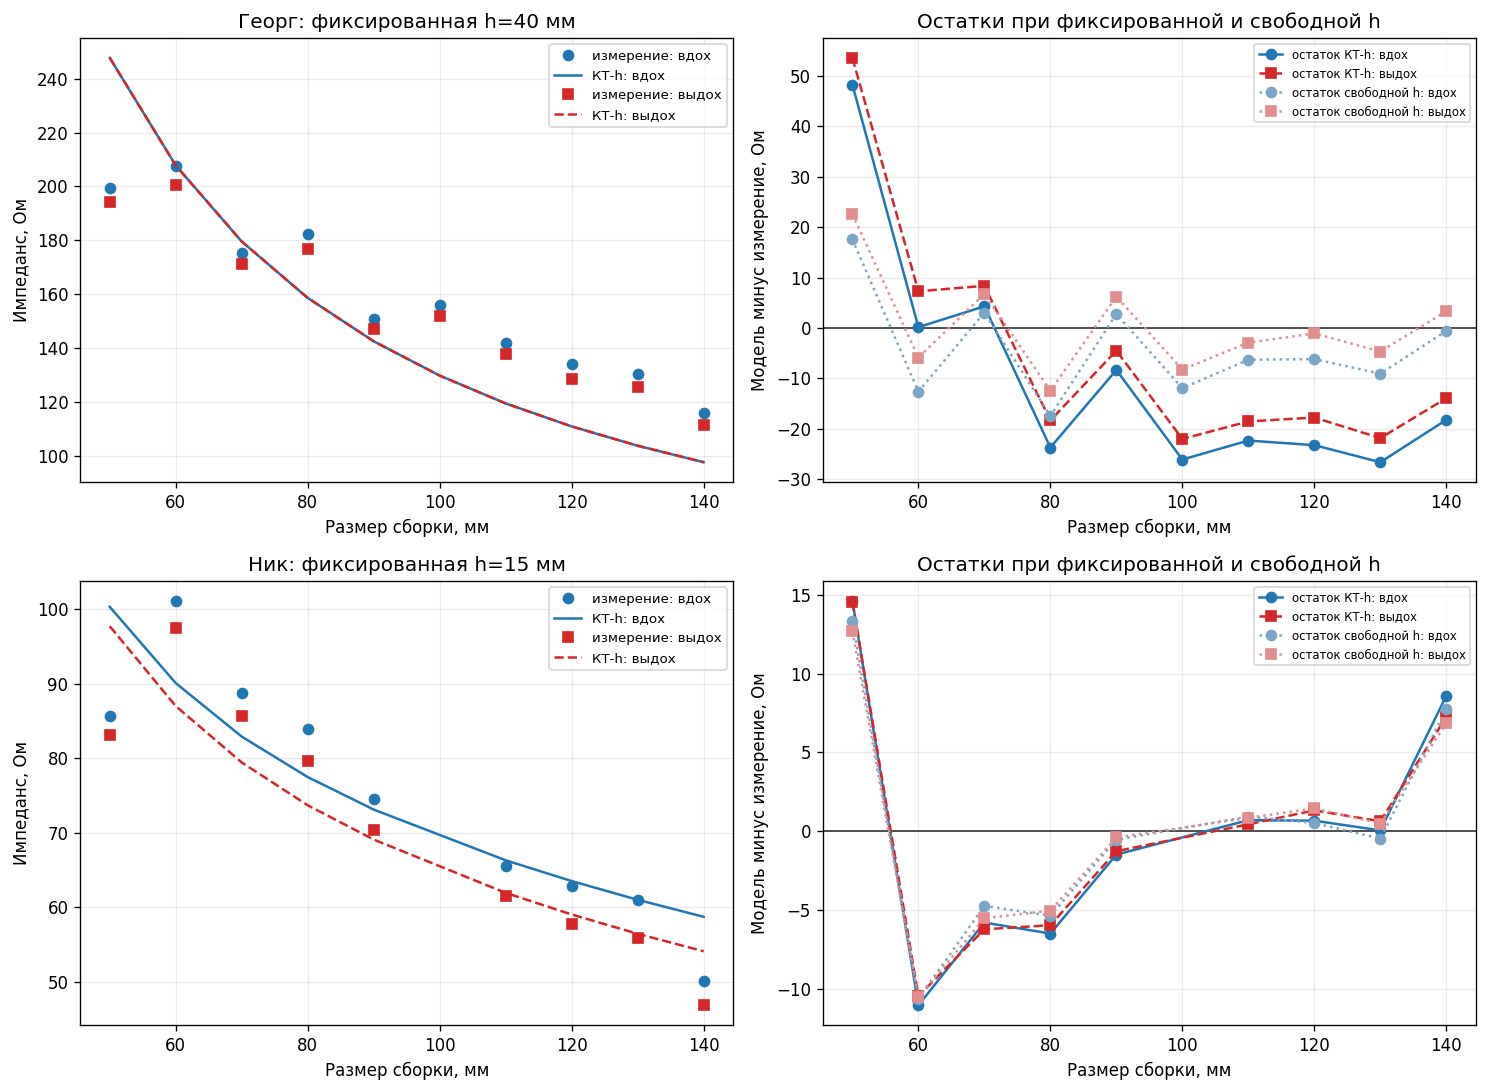

,Испытуемый,"ρ₁: минимум, Ом·м","ρ₁: максимум, Ом·м","ρ₂ на вдохе: минимум, Ом·м","ρ₂ на вдохе: максимум, Ом·м","ρ₂ на выдохе: минимум, Ом·м","ρ₂ на выдохе: максимум, Ом·м","RMS: минимум, Ом","RMS: максимум, Ом",Число граничных пересчётов
0,Георг,14.203,15.000,25.000,25.000,25.000,25.000,15.356,24.526,10
1,Ник,4.385,6.105,11.571,20.343,10.012,16.533,2.007,7.664,0


In [8]:
fig, axes = plt.subplots(len(ct_results), 2, figsize=(12.5, 4.6 * len(ct_results)))
if len(ct_results) == 1:
    axes = np.asarray([axes])

ct_loo_rows = []
for row_index, (subject_id, result) in enumerate(ct_results.items()):
    subject = source["subjects"][subject_id]
    sizes_m, z_inhale, z_exhale = subject_arrays(subject)
    sizes_mm = 1000.0 * sizes_m
    ct_fit = result["primary_fit"]
    free_fit = results[subject_id]["primary_fit"]

    ax = axes[row_index, 0]
    ax.plot(sizes_mm, z_inhale, "o", color="#1f77b4", label="измерение: вдох")
    ax.plot(sizes_mm, ct_fit["predicted_inhale_ohm"], "-", color="#1f77b4", label="КТ-h: вдох")
    ax.plot(sizes_mm, z_exhale, "s", color="#d62728", label="измерение: выдох")
    ax.plot(sizes_mm, ct_fit["predicted_exhale_ohm"], "--", color="#d62728", label="КТ-h: выдох")
    ax.set_xlabel("Размер сборки, мм")
    ax.set_ylabel("Импеданс, Ом")
    ax.set_title(
        f"{SUBJECT_NAMES.get(subject_id, subject_id)}: "
        f"фиксированная h={1000.0 * result['h_ct_m']:.0f} мм"
    )
    ax.legend(fontsize=8)

    ct_residual_in = np.asarray(ct_fit["predicted_inhale_ohm"]) - z_inhale
    ct_residual_ex = np.asarray(ct_fit["predicted_exhale_ohm"]) - z_exhale
    free_residual_in = np.asarray(free_fit["predicted_inhale_ohm"]) - z_inhale
    free_residual_ex = np.asarray(free_fit["predicted_exhale_ohm"]) - z_exhale
    ax = axes[row_index, 1]
    ax.axhline(0.0, color="#333333", linewidth=1)
    ax.plot(sizes_mm, ct_residual_in, "o-", color="#1f77b4", label="остаток КТ-h: вдох")
    ax.plot(sizes_mm, ct_residual_ex, "s--", color="#d62728", label="остаток КТ-h: выдох")
    ax.plot(sizes_mm, free_residual_in, "o:", color="#7aa6c9", label="остаток свободной h: вдох")
    ax.plot(sizes_mm, free_residual_ex, "s:", color="#e28e8e", label="остаток свободной h: выдох")
    ax.set_xlabel("Размер сборки, мм")
    ax.set_ylabel("Модель минус измерение, Ом")
    ax.set_title("Остатки при фиксированной и свободной h")
    ax.legend(fontsize=7)

    for item in result["leave_one_size_out"]:
        ct_loo_rows.append({
            "subject_id": subject_id,
            "Испытуемый": SUBJECT_NAMES.get(subject_id, subject_id),
            "Исключённый размер, мм": item["omitted_size_mm"],
            "ρ₁, Ом·м": item["rho1_ohm_m"],
            "ρ₂ на вдохе, Ом·м": item["rho2_inhale_ohm_m"],
            "ρ₂ на выдохе, Ом·м": item["rho2_exhale_ohm_m"],
            "RMS, Ом": item["residual_rms_ohm"],
            "Есть граничный параметр": any(item["parameter_bound_hits"].values()),
        })

plt.tight_layout()
plt.show()

ct_loo = pd.DataFrame(ct_loo_rows)
ct_loo_summary = (
    ct_loo.groupby("Испытуемый", sort=False)
    .agg(
        rho1_min=("ρ₁, Ом·м", "min"),
        rho1_max=("ρ₁, Ом·м", "max"),
        rho2_in_min=("ρ₂ на вдохе, Ом·м", "min"),
        rho2_in_max=("ρ₂ на вдохе, Ом·м", "max"),
        rho2_ex_min=("ρ₂ на выдохе, Ом·м", "min"),
        rho2_ex_max=("ρ₂ на выдохе, Ом·м", "max"),
        rms_min=("RMS, Ом", "min"),
        rms_max=("RMS, Ом", "max"),
        boundary_count=("Есть граничный параметр", "sum"),
    )
    .reset_index()
    .rename(columns={
        "rho1_min": "ρ₁: минимум, Ом·м",
        "rho1_max": "ρ₁: максимум, Ом·м",
        "rho2_in_min": "ρ₂ на вдохе: минимум, Ом·м",
        "rho2_in_max": "ρ₂ на вдохе: максимум, Ом·м",
        "rho2_ex_min": "ρ₂ на выдохе: минимум, Ом·м",
        "rho2_ex_max": "ρ₂ на выдохе: максимум, Ом·м",
        "rms_min": "RMS: минимум, Ом",
        "rms_max": "RMS: максимум, Ом",
        "boundary_count": "Число граничных пересчётов",
    })
)
display(ct_loo_summary.style.format({
    column: "{:.3f}"
    for column in ct_loo_summary.columns
    if column not in {"Испытуемый", "Число граничных пересчётов"}
}))


### Наблюдаемая структура на рисунке 4

Левые панели сопоставляют измеренные импедансы с расчётом, в котором $h$ зафиксирована по историческому КТ-референсу: 40 мм для Георга и 15 мм для Ника. Правые панели показывают остаток «модель минус измерение». Положительный остаток означает завышение импеданса моделью, отрицательный — занижение. Насыщенные линии относятся к КТ-сценарию, светлые пунктирные линии — к расчёту со свободной $h$.

У Георга расчётные линии вдоха и выдоха почти полностью совпадают, потому что обе оценки $\rho_2$ достигают верхней границы 25 Ом·м. Такое совпадение является результатом ограничения оптимизатора и не означает отсутствия дыхательной разницы. Форма остатков систематична: для сборки 50 мм модель завышает импеданс примерно на 50 Ом, тогда как для большей части диапазона 80–140 мм она его занижает. Чередование знака связано не с постоянным смещением всей кривой, а с несовпадением её формы с размерной зависимостью измерений. Светлые кривые свободной $h$ располагаются ближе к нулю, что соответствует росту RMS с 9,959 до 23,331 Ом после фиксации $h=40$ мм.

У Ника линии вдоха и выдоха разделены и проходят существенно ближе к наблюдаемым точкам. Остатки КТ-сценария и расчёта со свободной $h$ почти совпадают; RMS увеличивается только с 6,589 до 7,227 Ом. Наиболее выраженные отклонения сохраняются для 50, 60 и 140 мм. Следовательно, фиксация $h=15$ мм совместима с общей формой данных значительно лучше, чем фиксация $h=40$ мм у Георга, хотя межзаписные расхождения полностью не исчезают.

Таблица чувствительности под рисунком уточняет характер граничности. У Георга обе оценки $\rho_2$ достигают 25 Ом·м в основной области, 50 Ом·м после её расширения и 200 Ом·м в техническом сценарии. Одновременное движение к каждому новому пределу означает, что данные не задают конечного внутреннего значения $\rho_2$. Широкий технический предел используется только как диагностический тест и не получает физиологической интерпретации. У Ника оценки остаются равными 17,123 и 14,273 Ом·м при всех трёх диапазонах, что подтверждает наличие внутреннего минимума при фиксированной $h=15$ мм.

Проверка с исключением одной сборки даёт дополнительное различие. У Георга граничный параметр появляется во всех десяти повторных расчётах. У Ника ни один из девяти повторных расчётов не достигает границы, однако диапазон оценок заметно расширяется при исключении влиятельной сборки 50 мм.

**Вывод из рисунка 4.** Исторический КТ-референс 15 мм позволяет получить у Ника конечные условные оценки трёх удельных сопротивлений, но их устойчивость к отдельным записям ещё не доказана. При 40 мм у Георга текущая плоская двуслойная модель и записанные импедансы не определяют конечные $\rho_{2,\mathrm{вдох}}$ и $\rho_{2,\mathrm{выдох}}$. Рисунок указывает на несогласованность совокупности предпосылок, но не устанавливает, ошибочна ли КТ-толщина, эффективная интерпретация $h$, геометрия модели или экспериментальные записи.


In [9]:
georg = results["exp02_georg"]["primary_fit"]
nik = results["exp02_nik"]["primary_fit"]
nik_loo = loo[loo["subject_id"] == "exp02_nik"]
nik_influential = nik_loo.loc[nik_loo["h, мм"].idxmax()]
ct_georg = ct_results["exp02_georg"]["primary_fit"]
ct_nik = ct_results["exp02_nik"]["primary_fit"]
ct_georg_expanded = ct_results["exp02_georg"]["expanded_fit"]
ct_georg_technical = ct_results["exp02_georg"]["technical_fit"]

display(Markdown(f'''
## Вывод

При свободной $h$ минимум для обоих испытуемых остаётся на нижней границе основного диапазона, поэтому устойчивое внутреннее решение четырёх параметров не подтверждено.

Фиксация исторического КТ-референса даёт разные результаты у двух испытуемых. Для Ника при $h=15$ мм получены внутренние оценки $\\rho_1={ct_nik['rho1_ohm_m']:.3f}$ Ом·м, $\\rho_{{2,\\mathrm{{вдох}}}}={ct_nik['rho2_inhale_ohm_m']:.3f}$ Ом·м и $\\rho_{{2,\\mathrm{{выдох}}}}={ct_nik['rho2_exhale_ohm_m']:.3f}$ Ом·м. RMS равна {ct_nik['residual_rms_ohm']:.3f} Ом, что на {100.0 * (ct_nik['residual_rms_ohm'] / nik['residual_rms_ohm'] - 1.0):.1f} % выше результата со свободной $h$. Значения остаются внутри основной области, однако исключение сборки 50 мм заметно изменяет их, поэтому устойчивость к отдельным записям ещё не подтверждена.

Для Георга при $h=40$ мм обе оценки $\\rho_2$ достигают 25 Ом·м, а RMS возрастает до {ct_georg['residual_rms_ohm']:.3f} Ом — на {100.0 * (ct_georg['residual_rms_ohm'] / georg['residual_rms_ohm'] - 1.0):.1f} % относительно свободной $h$. После расширения области до 50 Ом·м обе оценки снова достигают верхней границы; при техническом пределе 200 Ом·м они также остаются на границе. Следовательно, при $h=40$ мм текущие данные и двуслойная модель не задают конечных внутренних значений $\\rho_{{2,\\mathrm{{вдох}}}}$ и $\\rho_{{2,\\mathrm{{выдох}}}}$.

Этот результат не опровергает КТ-толщину. Он показывает несогласованность совокупности из исторического КТ-референса, плоской двуслойной модели и последовательно записанных импедансов. Возможные объяснения следует проверять раздельно: различие анатомической и эффективной $h$, кривизна и неоднородность грудной стенки, недостаточная глубина чувствительности имеющихся сборок, межзаписная изменчивость и аппаратные эффекты.
'''))



## Вывод

При свободной $h$ минимум для обоих испытуемых остаётся на нижней границе основного диапазона, поэтому устойчивое внутреннее решение четырёх параметров не подтверждено.

Фиксация исторического КТ-референса даёт разные результаты у двух испытуемых. Для Ника при $h=15$ мм получены внутренние оценки $\rho_1=4.749$ Ом·м, $\rho_{2,\mathrm{вдох}}=17.123$ Ом·м и $\rho_{2,\mathrm{выдох}}=14.273$ Ом·м. RMS равна 7.227 Ом, что на 9.7 % выше результата со свободной $h$. Значения остаются внутри основной области, однако исключение сборки 50 мм заметно изменяет их, поэтому устойчивость к отдельным записям ещё не подтверждена.

Для Георга при $h=40$ мм обе оценки $\rho_2$ достигают 25 Ом·м, а RMS возрастает до 23.331 Ом — на 134.3 % относительно свободной $h$. После расширения области до 50 Ом·м обе оценки снова достигают верхней границы; при техническом пределе 200 Ом·м они также остаются на границе. Следовательно, при $h=40$ мм текущие данные и двуслойная модель не задают конечных внутренних значений $\rho_{2,\mathrm{вдох}}$ и $\rho_{2,\mathrm{выдох}}$.

Этот результат не опровергает КТ-толщину. Он показывает несогласованность совокупности из исторического КТ-референса, плоской двуслойной модели и последовательно записанных импедансов. Возможные объяснения следует проверять раздельно: различие анатомической и эффективной $h$, кривизна и неоднородность грудной стенки, недостаточная глубина чувствительности имеющихся сборок, межзаписная изменчивость и аппаратные эффекты.


In [10]:
def json_ready(value):
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    return value


artifact = {
    "artifact_id": "33.07_joint_bounded_two_layer_solution",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "scope": "method_development_not_validated",
    "source_artifact": str(SOURCE_PATH),
    "source_sha256": hashlib.sha256(SOURCE_PATH.read_bytes()).hexdigest(),
    "parameterization_per_subject": [
        "h_m",
        "rho1_ohm_m",
        "rho2_inhale_ohm_m",
        "rho2_exhale_ohm_m",
    ],
    "primary_bounds": PRIMARY,
    "expanded_sensitivity_bounds": EXPANDED,
    "historical_ct_reference_h_m": CT_H_M,
    "historical_ct_reference_status": "transferred_from_manual_ct_segmentation_not_recomputed_here",
    "criterion": "unweighted RMS of impedance residuals across assemblies and two respiratory states",
    "subjects": {
        subject_id: {
            "primary_fit": result["primary_fit"],
            "expanded_fit": result["expanded_fit"],
            "primary_profile": result["primary_profile"],
            "expanded_profile": result["expanded_profile"],
            "exact_inversion_consistency_diagnostic": diagnostics[subject_id],
            "leave_one_size_out": loo[loo["subject_id"] == subject_id].to_dict(orient="records"),
            "ct_fixed_h": ct_results[subject_id],
            "stable_internal_solution_confirmed": False,
        }
        for subject_id, result in results.items()
    },
    "limitations": [
        "physiological bounds are provisional working assumptions",
        "all residuals have equal weight because measurement uncertainty is not established",
        "sequential assembly records are assumed comparable",
        "historical CT thickness is not recomputed from DICOM, masks or STL in this notebook",
        "effective h is not validated as equivalent to anatomical CT thickness",
        "two-layer model is assumed applicable but not independently validated here",
    ],
}

ARTIFACT_PATH = (
    Path(config["derived_root"])
    / "exp02"
    / "exploratory"
    / "33.07_joint_bounded_two_layer_solution.json"
)
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
ARTIFACT_PATH.write_text(
    json.dumps(json_ready(artifact), ensure_ascii=False, indent=2),
    encoding="utf-8",
)

display(Markdown(f'''
## Происхождение результата

- Источник статических импедансов: `{SOURCE_PATH}`.
- Контрольная сумма источника SHA-256: `{artifact['source_sha256']}`.
- Расчётный артефакт: `{ARTIFACT_PATH}`.
- Статус: разработка методики; устойчивое внутреннее решение не подтверждено.
'''))



## Происхождение результата

- Источник статических импедансов: `D:\Аспа\Bitrix\ЭИТЛ\01 Project\01 Experiments\_Kalmykov_PhD_derived\exp02\exploratory\33.06_side_arrays_exploratory.json`.
- Контрольная сумма источника SHA-256: `0ff279299d7f040df52f3a67525ba5df764013661a01de69d76b64babb23c11c`.
- Расчётный артефакт: `D:\Аспа\Bitrix\ЭИТЛ\01 Project\01 Experiments\_Kalmykov_PhD_derived\exp02\exploratory\33.07_joint_bounded_two_layer_solution.json`.
- Статус: разработка методики; устойчивое внутреннее решение не подтверждено.
